In [1]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [2]:
import pandas as pd

# Load all 9 datasets
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

# Check shape of each table
datasets = {
    'orders': orders,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_translation': category_translation
}

for name, df in datasets.items():
    print(f"{name:25s} → {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols")

orders                    →  99,441 rows ×  8 cols
order_items               → 112,650 rows ×  7 cols
order_payments            → 103,886 rows ×  5 cols
order_reviews             →  99,224 rows ×  7 cols
customers                 →  99,441 rows ×  5 cols
products                  →  32,951 rows ×  9 cols
sellers                   →   3,095 rows ×  4 cols
geolocation               → 1,000,163 rows ×  5 cols
category_translation      →      71 rows ×  2 cols


In [3]:
# Check order_status distribution
# We need to understand what statuses exist before deciding what to remove
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [4]:
# Keep only orders that actually reached the customer
# canceled, unavailable, processing etc. are excluded
# because they don't represent completed transactions
valid_status = ['delivered', 'shipped']
orders_clean = orders[orders['order_status'].isin(valid_status)].copy()

print(f"Before: {len(orders):,} rows")
print(f"After:  {len(orders_clean):,} rows")
print(f"Removed: {len(orders) - len(orders_clean):,} rows")

Before: 99,441 rows
After:  97,585 rows
Removed: 1,856 rows


In [5]:
# Convert date columns from string to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

print(f"Order date range:")
print(f"  Earliest: {orders_clean['order_purchase_timestamp'].min()}")
print(f"  Latest:   {orders_clean['order_purchase_timestamp'].max()}")

late_deliveries = orders_clean[
    orders_clean['order_delivered_customer_date'] >
    orders_clean['order_estimated_delivery_date']
]
print(f"\nLate deliveries: {len(late_deliveries):,} out of {len(orders_clean):,}")
print(f"Late delivery rate: {len(late_deliveries)/len(orders_clean)*100:.1f}%")

Order date range:
  Earliest: 2016-09-04 21:15:19
  Latest:   2018-09-03 09:06:57

Late deliveries: 7,826 out of 97,585
Late delivery rate: 8.0%


In [6]:
orders_canceled = orders[orders['order_status'] == 'canceled'].copy()
print(f"Canceled orders: {len(orders_canceled):,}")
print(f"Main analysis dataset: {len(orders_clean):,} rows")

Canceled orders: 625
Main analysis dataset: 97,585 rows


In [7]:
# Create delivery_days column
# = actual days taken from purchase to delivery
# This will be our key variable for delivery analysis
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

# Create is_late column (1 = late, 0 = on time)
# = 1 if actual delivery > estimated delivery date
orders_clean['is_late'] = (
    orders_clean['order_delivered_customer_date'] >
    orders_clean['order_estimated_delivery_date']
).astype(int)

# Quick check
print(orders_clean[['order_purchase_timestamp',
                     'order_delivered_customer_date',
                     'delivery_days',
                     'is_late']].head(10))
print(f"\nAvg delivery days: {orders_clean['delivery_days'].mean():.1f}")
print(f"Max delivery days: {orders_clean['delivery_days'].max():.0f}")
print(f"Min delivery days: {orders_clean['delivery_days'].min():.0f}")

   order_purchase_timestamp order_delivered_customer_date  delivery_days  \
0       2017-10-02 10:56:33           2017-10-10 21:25:13            8.0   
1       2018-07-24 20:41:37           2018-08-07 15:27:45           13.0   
2       2018-08-08 08:38:49           2018-08-17 18:06:29            9.0   
3       2017-11-18 19:28:06           2017-12-02 00:28:42           13.0   
4       2018-02-13 21:18:39           2018-02-16 18:17:02            2.0   
5       2017-07-09 21:57:05           2017-07-26 10:57:55           16.0   
7       2017-05-16 13:10:30           2017-05-26 12:55:51            9.0   
8       2017-01-23 18:29:09           2017-02-02 14:08:10            9.0   
9       2017-07-29 11:55:02           2017-08-16 17:14:30           18.0   
10      2017-05-16 19:41:10           2017-05-29 11:18:31           12.0   

    is_late  
0         0  
1         0  
2         0  
3         0  
4         0  
5         0  
7         0  
8         0  
9         0  
10        0  

Avg deli

In [8]:
# Check suspicious delivery_days values
# 0 days = same day delivery is unrealistic for Brazilian e-commerce
# 209 days = likely a data error or extreme outlier
print("Distribution of delivery_days:")
print(orders_clean['delivery_days'].describe())

# Check how many orders have 0 or negative delivery days
print(f"\nOrders with 0 delivery days: {(orders_clean['delivery_days'] == 0).sum()}")
print(f"Orders with delivery > 60 days: {(orders_clean['delivery_days'] > 60).sum()}")

# Remove extreme outliers
# Keep only orders where delivery took between 1 and 60 days
# 60 days = 2 months, a reasonable upper limit for Brazilian logistics
orders_clean = orders_clean[
    (orders_clean['delivery_days'] >= 1) &
    (orders_clean['delivery_days'] <= 60)
].copy()

print(f"\nAfter removing outliers: {len(orders_clean):,} rows")

Distribution of delivery_days:
count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

Orders with 0 delivery days: 13
Orders with delivery > 60 days: 288

After removing outliers: 96,169 rows


In [9]:
# Merge all tables into one master dataframe
# Start from orders_clean as the base (left table)
# Join step by step to understand what each join adds

# Step 1: orders + customers (add customer location info)
df = orders_clean.merge(customers, on='customer_id', how='left')
print(f"After joining customers: {df.shape}")

# Step 2: + order_items (add product & price info)
df = df.merge(order_items, on='order_id', how='left')
print(f"After joining order_items: {df.shape}")

# Step 3: + order_payments (add payment info)
payments_agg = order_payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')
print(f"After joining payments: {df.shape}")

# Step 4: + order_reviews (add review scores)
reviews_agg = order_reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()
df = df.merge(reviews_agg, on='order_id', how='left')
print(f"After joining reviews: {df.shape}")

# Step 5: + products + category translation (add category in English)
products_translated = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)
df = df.merge(products_translated[['product_id', 'product_category_name_english']],
              on='product_id', how='left')
print(f"After joining products: {df.shape}")

# Step 6: + sellers (add seller location)
df = df.merge(sellers[['seller_id', 'seller_state']],
              on='seller_id', how='left')
print(f"\nFinal master dataframe: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

After joining customers: (96169, 14)
After joining order_items: (109860, 20)
After joining payments: (109860, 22)
After joining reviews: (109860, 23)
After joining products: (109860, 24)

Final master dataframe: (109860, 25)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'is_late', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_value', 'payment_type', 'review_score', 'product_category_name_english', 'seller_state']


In [10]:
# Check missing values in the master dataframe
# We need to know which columns have NaN before analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(missing_report)

                               missing_count  missing_pct
product_category_name_english           1554          1.4
review_score                             811          0.7
order_delivered_carrier_date               1          0.0
order_approved_at                         15          0.0
payment_type                               3          0.0
payment_value                              3          0.0


In [11]:
# All missing values are under 5% → safe to drop rows
# review_score is especially important for our analysis
# so we must not keep rows without it
before = len(df)
df = df.dropna(subset=[
    'product_category_name_english',
    'review_score',
    'order_delivered_carrier_date',
    'order_approved_at',
    'payment_type',
    'payment_value'
])
after = len(df)

print(f"Before: {before:,} rows")
print(f"After:  {after:,} rows")
print(f"Dropped: {before - after:,} rows ({(before-after)/before*100:.1f}%)")

# Confirm no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Before: 109,860 rows
After:  107,489 rows
Dropped: 2,371 rows (2.2%)

Remaining missing values: 0


In [12]:
# Map Brazilian state abbreviations to full English names
# This makes visualizations more readable
state_map = {
    'SP': 'São Paulo', 'RJ': 'Rio de Janeiro', 'MG': 'Minas Gerais',
    'RS': 'Rio Grande do Sul', 'PR': 'Paraná', 'SC': 'Santa Catarina',
    'BA': 'Bahia', 'GO': 'Goiás', 'ES': 'Espírito Santo',
    'PE': 'Pernambuco', 'CE': 'Ceará', 'PA': 'Pará',
    'MT': 'Mato Grosso', 'MA': 'Maranhão', 'MS': 'Mato Grosso do Sul',
    'DF': 'Distrito Federal', 'AM': 'Amazonas', 'PB': 'Paraíba',
    'RN': 'Rio Grande do Norte', 'PI': 'Piauí', 'AL': 'Alagoas',
    'SE': 'Sergipe', 'RO': 'Rondônia', 'TO': 'Tocantins',
    'AC': 'Acre', 'AP': 'Amapá', 'RR': 'Roraima'
}

# Add full state name columns for both customer and seller
df['customer_state_name'] = df['customer_state'].map(state_map)
df['seller_state_name'] = df['seller_state'].map(state_map)

print(df[['customer_state', 'customer_state_name',
          'seller_state', 'seller_state_name']].head(5))

  customer_state  customer_state_name seller_state seller_state_name
0             SP            São Paulo           SP         São Paulo
1             BA                Bahia           SP         São Paulo
2             GO                Goiás           SP         São Paulo
3             RN  Rio Grande do Norte           MG      Minas Gerais
4             SP            São Paulo           SP         São Paulo


In [13]:
# Save cleaned master dataframe
df.to_csv('olist_master.csv', index=False)
print(f"Saved! Final shape: {df.shape}")

Saved! Final shape: (107489, 27)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== OVERALL SUMMARY ===")
print(f"Total orders:            {df['order_id'].nunique():>10,}")
print(f"Total revenue:           R${df['payment_value'].sum():>10,.0f}")
print(f"Avg order value:         R${df['payment_value'].mean():>10.2f}")
print(f"Avg review score:        {df['review_score'].mean():>10.2f} / 5.0")
print(f"Avg delivery days:       {df['delivery_days'].mean():>10.1f} days")
print(f"Late delivery rate:      {df['is_late'].mean()*100:>10.1f}%")
print(f"Unique customers:        {df['customer_id'].nunique():>10,}")
print(f"Unique sellers:          {df['seller_id'].nunique():>10,}")
print(f"Unique categories:       {df['product_category_name_english'].nunique():>10,}")
print(f"States covered:          {df['customer_state'].nunique():>10,}")

=== OVERALL SUMMARY ===
Total orders:                94,184
Total revenue:           R$19,245,454
Avg order value:         R$    179.05
Avg review score:              4.09 / 5.0
Avg delivery days:             11.8 days
Late delivery rate:             7.5%
Unique customers:            94,184
Unique sellers:               2,903
Unique categories:               71
States covered:                  27


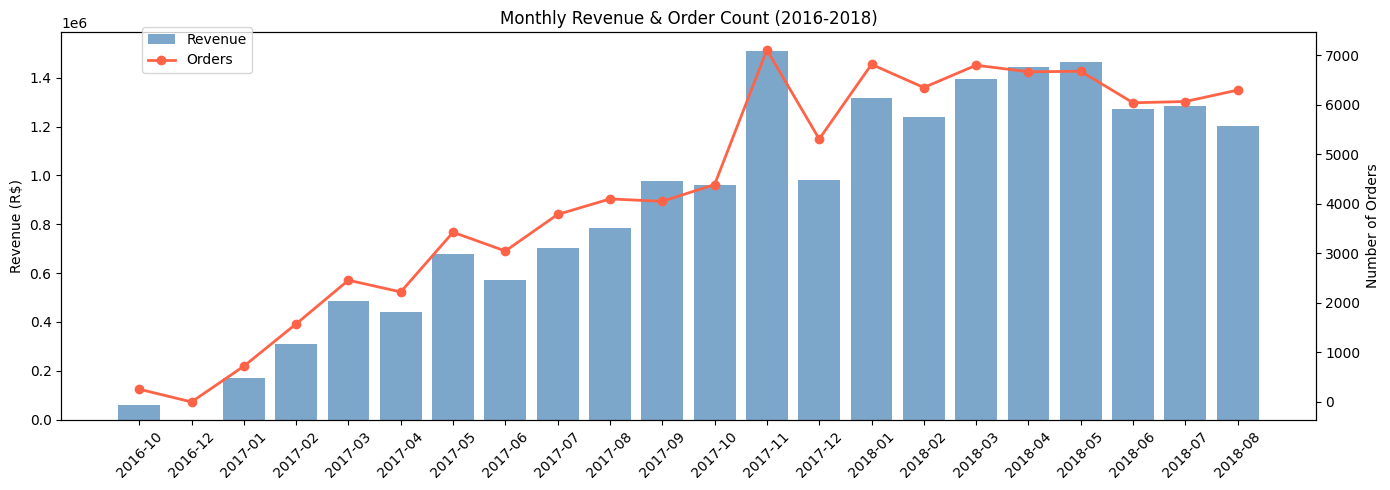

In [15]:
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('year_month').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly_revenue['year_month'], monthly_revenue['revenue'],
        color='steelblue', alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue (R$)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_revenue['year_month'], monthly_revenue['orders'],
         color='tomato', marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Number of Orders')

plt.title('Monthly Revenue & Order Count (2016-2018)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

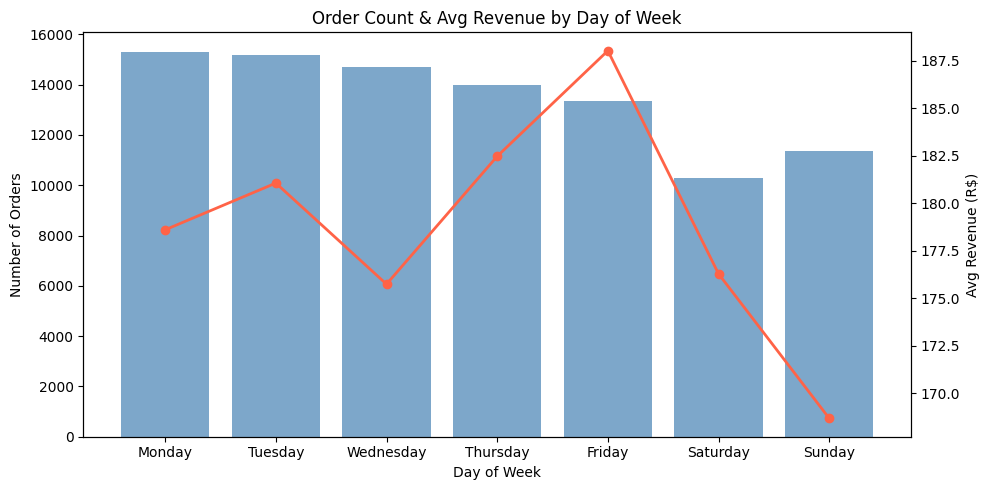

In [16]:
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_stats = df.groupby('day_of_week').agg(
    orders=('order_id', 'nunique'),
    avg_revenue=('payment_value', 'mean')
).reindex(day_order).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(day_stats['day_of_week'], day_stats['orders'],
               color='steelblue', alpha=0.7)
ax1.set_ylabel('Number of Orders')
ax1.set_xlabel('Day of Week')

ax2 = ax1.twinx()
ax2.plot(day_stats['day_of_week'], day_stats['avg_revenue'],
         color='tomato', marker='o', linewidth=2)
ax2.set_ylabel('Avg Revenue (R$)')

plt.title('Order Count & Avg Revenue by Day of Week')
plt.tight_layout()
plt.show()

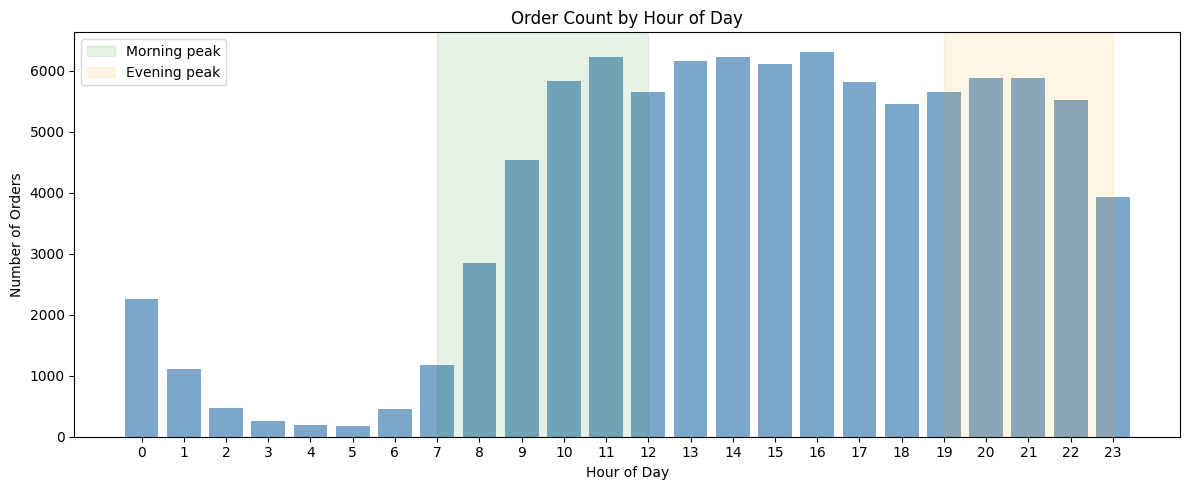

In [17]:
df['hour'] = df['order_purchase_timestamp'].dt.hour

hourly_stats = df.groupby('hour').agg(
    orders=('order_id', 'nunique')
).reset_index()

plt.figure(figsize=(12, 5))
plt.bar(hourly_stats['hour'], hourly_stats['orders'], color='steelblue', alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title('Order Count by Hour of Day')
plt.xticks(range(0, 24))
plt.axvspan(7, 12, alpha=0.1, color='green', label='Morning peak')
plt.axvspan(19, 23, alpha=0.1, color='orange', label='Evening peak')
plt.legend()
plt.tight_layout()
plt.show()

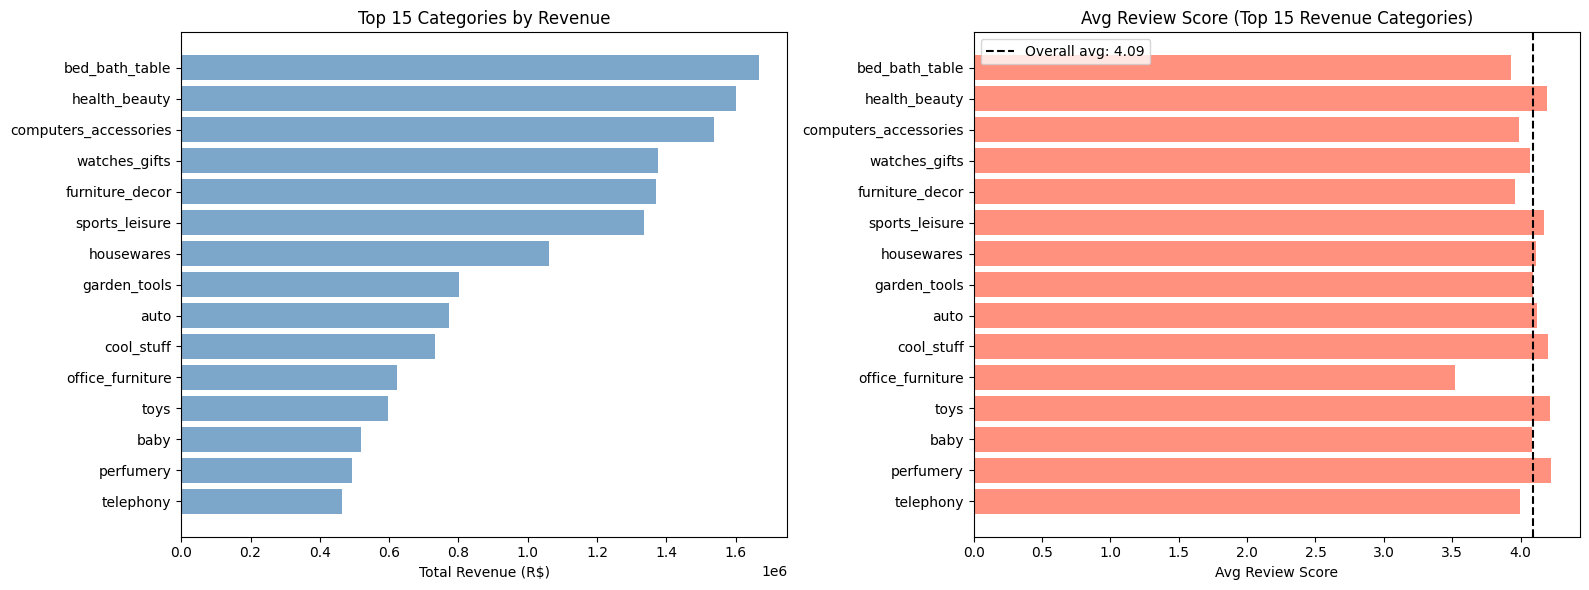

In [18]:
category_stats = df.groupby('product_category_name_english').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique'),
    avg_review=('review_score', 'mean')
).reset_index().sort_values('revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(category_stats['product_category_name_english'][::-1],
             category_stats['revenue'][::-1], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].set_title('Top 15 Categories by Revenue')

axes[1].barh(category_stats['product_category_name_english'][::-1],
             category_stats['avg_review'][::-1], color='tomato', alpha=0.7)
axes[1].set_xlabel('Avg Review Score')
axes[1].set_title('Avg Review Score (Top 15 Revenue Categories)')
axes[1].axvline(x=df['review_score'].mean(), color='black',
                linestyle='--', label=f'Overall avg: {df["review_score"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# Check actual review score range by category
print(category_stats[['product_category_name_english', 'avg_review']].to_string())

   product_category_name_english  avg_review
7                 bed_bath_table    3.929955
43                 health_beauty    4.195013
15         computers_accessories    3.991430
70                 watches_gifts    4.071835
39               furniture_decor    3.959908
65                sports_leisure    4.170497
49                    housewares    4.110946
42                  garden_tools    4.091393
5                           auto    4.124234
20                    cool_stuff    4.200436
57              office_furniture    3.524189
69                          toys    4.212209
6                           baby    4.082966
59                     perfumery    4.224013
68                     telephony    3.998179


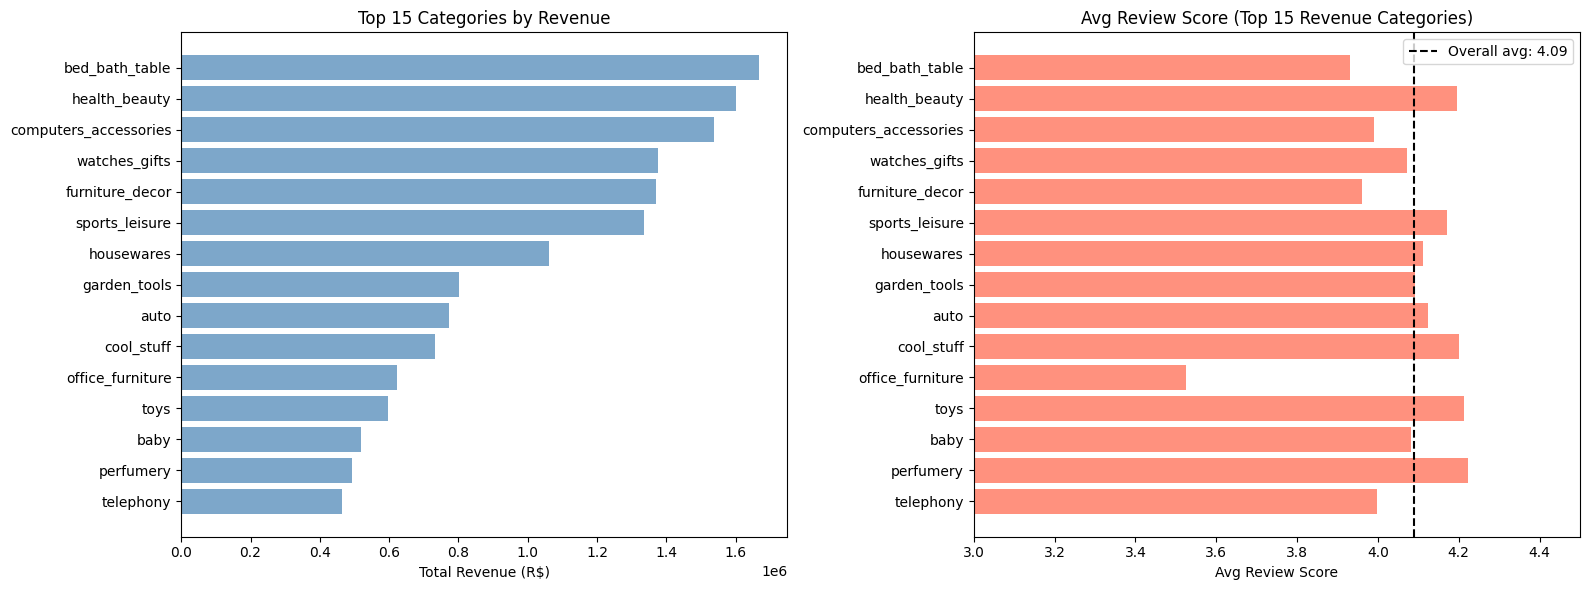

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(category_stats['product_category_name_english'][::-1],
             category_stats['revenue'][::-1], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].set_title('Top 15 Categories by Revenue')

axes[1].barh(category_stats['product_category_name_english'][::-1],
             category_stats['avg_review'][::-1], color='tomato', alpha=0.7)
axes[1].set_xlabel('Avg Review Score')
axes[1].set_title('Avg Review Score (Top 15 Revenue Categories)')
axes[1].set_xlim(3.0, 4.5)
axes[1].axvline(x=df['review_score'].mean(), color='black',
                linestyle='--', label=f'Overall avg: {df["review_score"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

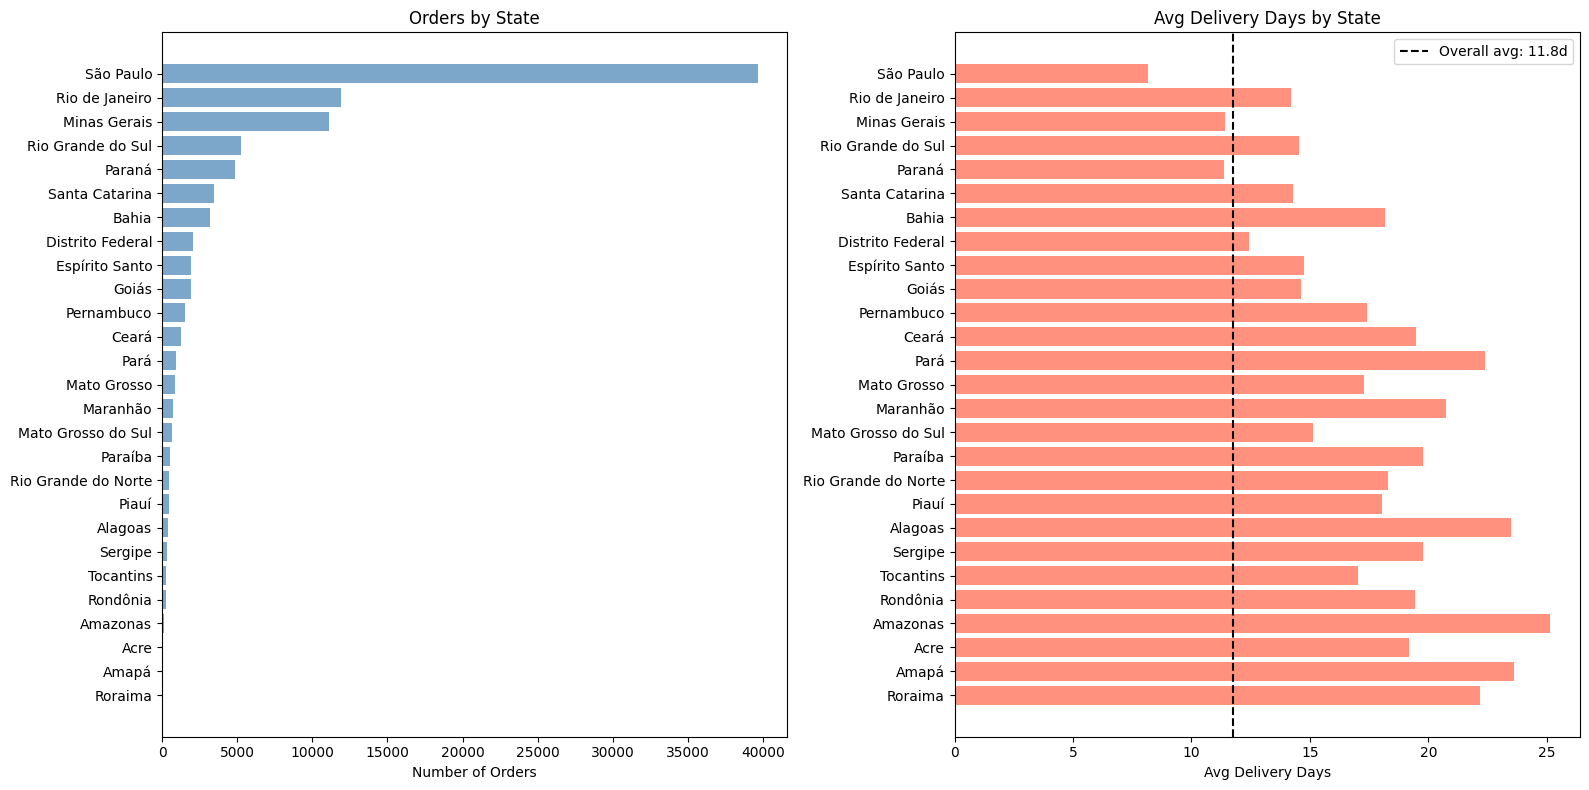

In [21]:
state_stats = df.groupby(['customer_state', 'customer_state_name']).agg(
    orders=('order_id', 'nunique'),
    revenue=('payment_value', 'sum'),
    avg_review=('review_score', 'mean'),
    avg_delivery=('delivery_days', 'mean')
).reset_index().sort_values('orders', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(state_stats['customer_state_name'][::-1],
             state_stats['orders'][::-1], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Orders by State')

axes[1].barh(state_stats['customer_state_name'][::-1],
             state_stats['avg_delivery'][::-1], color='tomato', alpha=0.7)
axes[1].set_xlabel('Avg Delivery Days')
axes[1].set_title('Avg Delivery Days by State')
axes[1].axvline(x=df['delivery_days'].mean(), color='black',
                linestyle='--', label=f'Overall avg: {df["delivery_days"].mean():.1f}d')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2293/335384673.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([on_time, late], labels=['On Time', 'Late'])


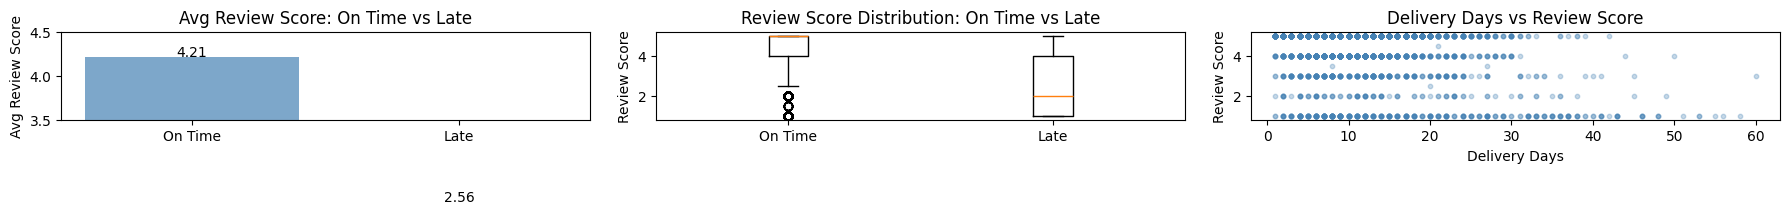

On Time  - Avg review: 4.213 (n=99,404)
Late     - Avg review: 2.564 (n=8,085)
Difference: 1.649


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Avg review score by is_late
late_review = df.groupby('is_late')['review_score'].mean().reset_index()
late_review['label'] = late_review['is_late'].map({0: 'On Time', 1: 'Late'})

axes[0].bar(late_review['label'], late_review['review_score'],
            color=['steelblue', 'tomato'], alpha=0.7)
axes[0].set_ylabel('Avg Review Score')
axes[0].set_title('Avg Review Score: On Time vs Late')
axes[0].set_ylim(3.5, 4.5)
for i, v in enumerate(late_review['review_score']):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Plot 2: Review score distribution by is_late (boxplot)
on_time = df[df['is_late'] == 0]['review_score']
late = df[df['is_late'] == 1]['review_score']

axes[1].boxplot([on_time, late], labels=['On Time', 'Late'])
axes[1].set_ylabel('Review Score')
axes[1].set_title('Review Score Distribution: On Time vs Late')

# Plot 3: Delivery days vs review score (scatter)
sample = df.sample(3000, random_state=42)
axes[2].scatter(sample['delivery_days'], sample['review_score'],
                alpha=0.3, color='steelblue', s=10)
axes[2].set_xlabel('Delivery Days')
axes[2].set_ylabel('Review Score')
axes[2].set_title('Delivery Days vs Review Score')

plt.tight_layout()
plt.show()

# Print numbers
print(f"On Time  - Avg review: {on_time.mean():.3f} (n={len(on_time):,})")
print(f"Late     - Avg review: {late.mean():.3f} (n={len(late):,})")
print(f"Difference: {on_time.mean() - late.mean():.3f}")

In [23]:
from scipy import stats

on_time_scores = df[df['is_late'] == 0]['review_score']
late_scores = df[df['is_late'] == 1]['review_score']

t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores)

print("=== T-TEST: On Time vs Late Delivery ===")
print(f"On Time  - Mean: {on_time_scores.mean():.3f}, Std: {on_time_scores.std():.3f}")
print(f"Late     - Mean: {late_scores.mean():.3f}, Std: {late_scores.std():.3f}")
print(f"Difference: {on_time_scores.mean() - late_scores.mean():.3f}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.10f}")
print(f"\nConclusion: {'Reject H0 (significant difference)' if p_value < 0.05 else 'Fail to reject H0 (no significant difference)'}")

=== T-TEST: On Time vs Late Delivery ===
On Time  - Mean: 4.213, Std: 1.229
Late     - Mean: 2.564, Std: 1.661
Difference: 1.649

t-statistic: 112.5800
p-value:     0.0000000000

Conclusion: Reject H0 (significant difference)


In [24]:
# Split into North (slow) vs South (fast) regions
north_states = ['AM', 'PA', 'RR', 'AP', 'AC', 'RO', 'TO', 'MA']
south_states = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC']

north = df[df['customer_state'].isin(north_states)]['review_score']
south = df[df['customer_state'].isin(south_states)]['review_score']

t_stat2, p_value2 = stats.ttest_ind(south, north)

print("=== T-TEST: South vs North Region Review Score ===")
print(f"South - Mean: {south.mean():.3f}, n={len(south):,}")
print(f"North - Mean: {north.mean():.3f}, n={len(north):,}")
print(f"Difference: {south.mean() - north.mean():.3f}")
print(f"\nt-statistic: {t_stat2:.4f}")
print(f"p-value:     {p_value2:.10f}")
print(f"\nConclusion: {'Reject H0 (significant difference)' if p_value2 < 0.05 else 'Fail to reject H0'}")

=== T-TEST: South vs North Region Review Score ===
South - Mean: 4.114, n=87,293
North - Mean: 3.923, n=2,721
Difference: 0.192

t-statistic: 7.4072
p-value:     0.0000000000

Conclusion: Reject H0 (significant difference)


In [25]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['payment_type'], df['is_late'])
print("Contingency Table:")
print(contingency_table)
print()

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("=== CHI-SQUARE TEST: Payment Type vs Late Delivery ===")
print(f"chi2-statistic: {chi2:.4f}")
print(f"p-value:        {p:.10f}")
print(f"degrees of freedom: {dof}")
print(f"\nConclusion: {'Reject H0 (significant association)' if p < 0.05 else 'Fail to reject H0'}")
print()

late_rate = df.groupby('payment_type')['is_late'].mean() * 100
print("Late delivery rate by payment type:")
print(late_rate.round(2))

Contingency Table:
is_late           0     1
payment_type             
boleto        20019  1793
credit_card   75339  5985
debit_card     1485   125
voucher        2561   182

=== CHI-SQUARE TEST: Payment Type vs Late Delivery ===
chi2-statistic: 21.6148
p-value:        0.0000784453
degrees of freedom: 3

Conclusion: Reject H0 (significant association)

Late delivery rate by payment type:
payment_type
boleto         8.22
credit_card    7.36
debit_card     7.76
voucher        6.64
Name: is_late, dtype: float64


In [26]:
from google.colab import files

# Monthly revenue
monthly_revenue.to_csv('tableau_monthly.csv', index=False)
files.download('tableau_monthly.csv')

# Category stats
category_stats.to_csv('tableau_category.csv', index=False)
files.download('tableau_category.csv')

# State stats
state_stats.to_csv('tableau_state.csv', index=False)
files.download('tableau_state.csv')

# Late vs on time summary
late_summary = df.groupby('is_late').agg(
    avg_review=('review_score', 'mean'),
    count=('order_id', 'nunique')
).reset_index()
late_summary['label'] = late_summary['is_late'].map({0: 'On Time', 1: 'Late'})
late_summary.to_csv('tableau_late_review.csv', index=False)
files.download('tableau_late_review.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from google.colab import files

state_stats.to_csv('tableau_state.csv', index=False)
files.download('tableau_state.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files

state_map_tableau = df.groupby('customer_state').agg(
    avg_delivery=('delivery_days', 'mean'),
    avg_review=('review_score', 'mean'),
    orders=('order_id', 'nunique'),
    revenue=('payment_value', 'sum')
).reset_index()

state_map_tableau.columns = ['State', 'Avg_Delivery', 'Avg_Review', 'Orders', 'Revenue']
state_map_tableau['Avg_Delivery'] = state_map_tableau['Avg_Delivery'].round(1)
state_map_tableau['Avg_Review'] = state_map_tableau['Avg_Review'].round(2)
state_map_tableau['Country'] = 'Brazil'

print(state_map_tableau)
state_map_tableau.to_csv('tableau_state_map.csv', index=False)
files.download('tableau_state_map.csv')

   State  Avg_Delivery  Avg_Review  Orders     Revenue Country
0     AC          19.2        4.18      76    23408.88  Brazil
1     AL          23.5        3.84     387   104650.72  Brazil
2     AM          25.1        4.14     142    32942.30  Brazil
3     AP          23.6        4.24      65    20941.25  Brazil
4     BA          18.2        3.88    3161   743745.85  Brazil
5     CE          19.5        3.91    1240   321681.87  Brazil
6     DF          12.4        4.06    2039   414953.51  Brazil
7     ES          14.7        4.02    1945   381597.99  Brazil
8     GO          14.6        4.05    1897   433735.26  Brazil
9     MA          20.7        3.77     699   191375.04  Brazil
10    MG          11.4        4.12   11106  2233435.67  Brazil
11    MS          15.1        4.07     690   161670.37  Brazil
12    MT          17.3        4.01     866   247999.56  Brazil
13    PA          22.4        3.85     906   231160.62  Brazil
14    PB          19.8        4.04     501   171043.30 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>